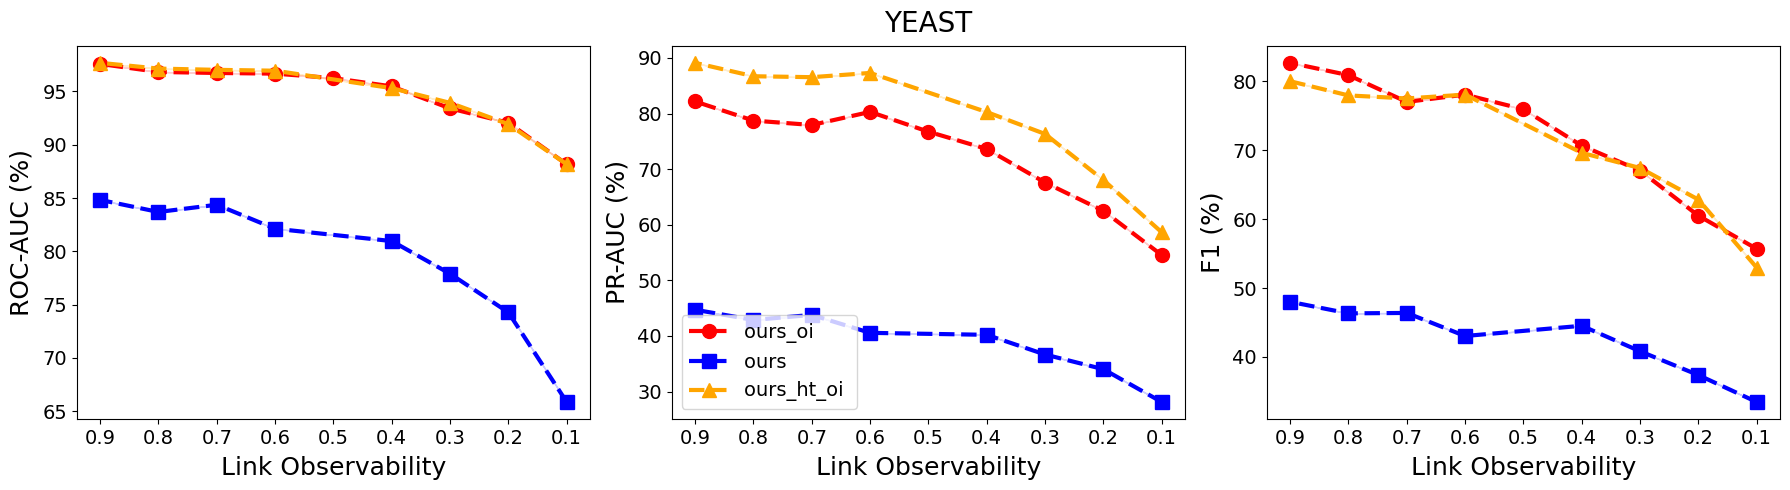

[INFO] 保存图表：yeast_metrics.pdf


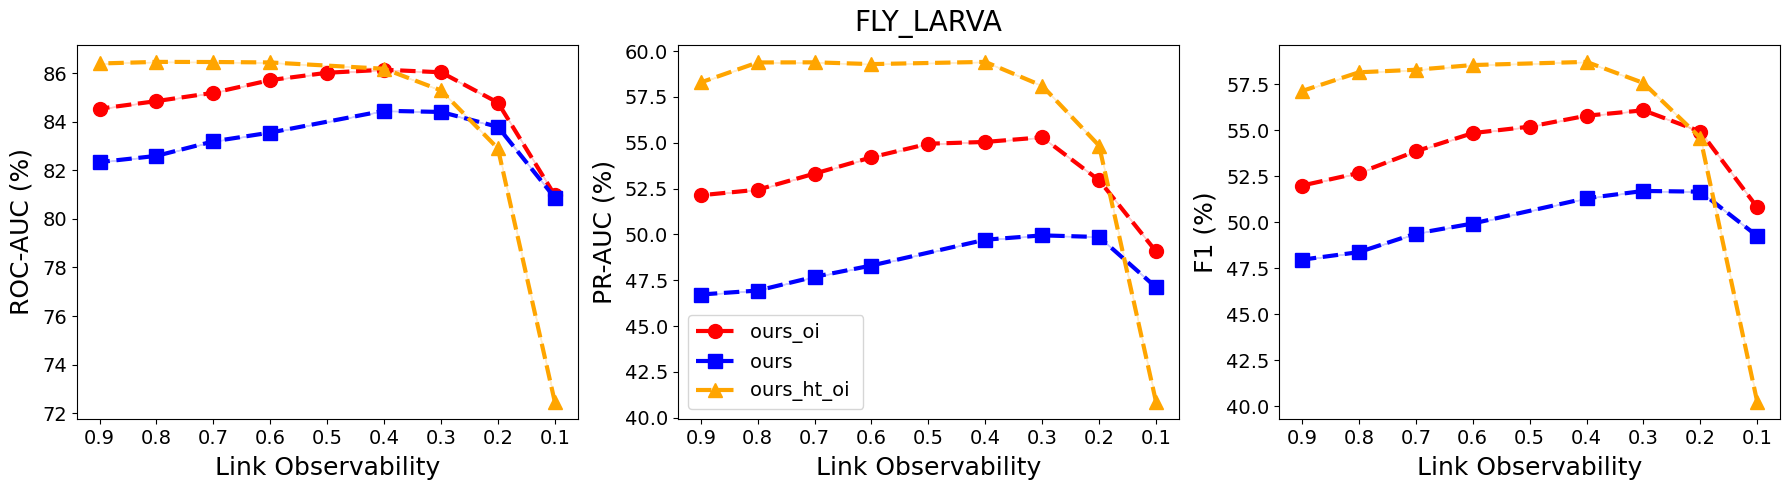

[INFO] 保存图表：fly_larva_metrics.pdf


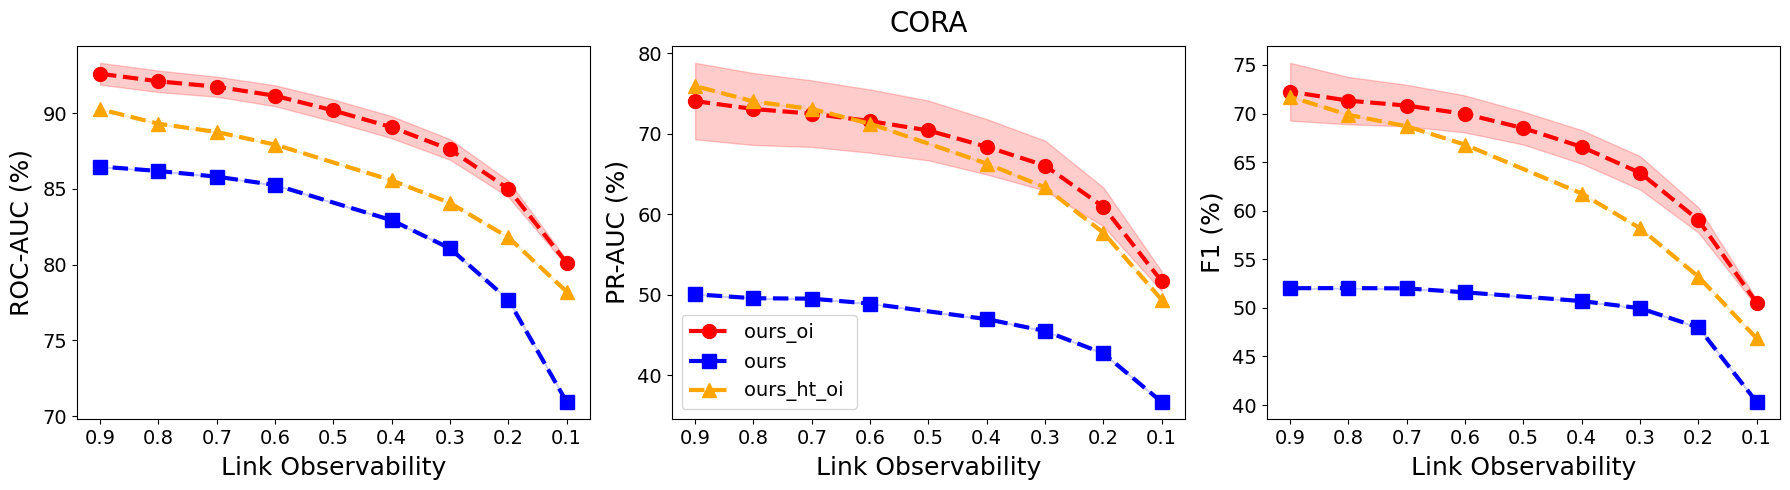

[INFO] 保存图表：cora_metrics.pdf


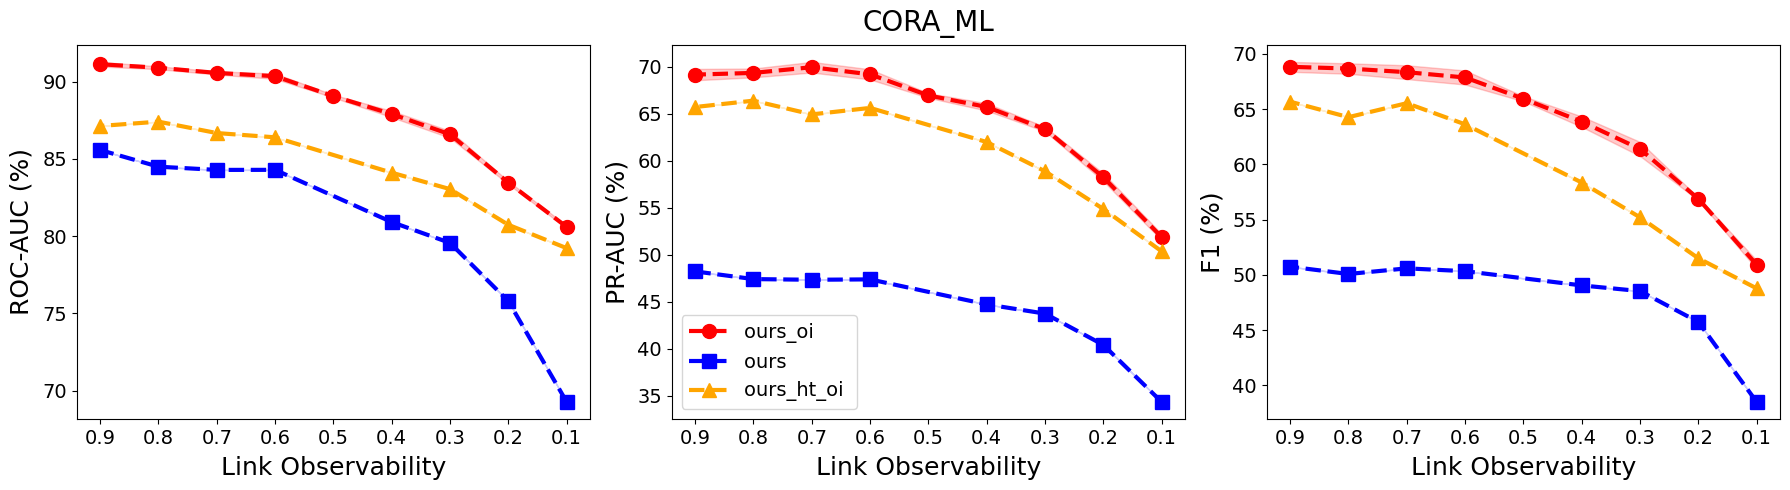

[INFO] 保存图表：cora_ml_metrics.pdf


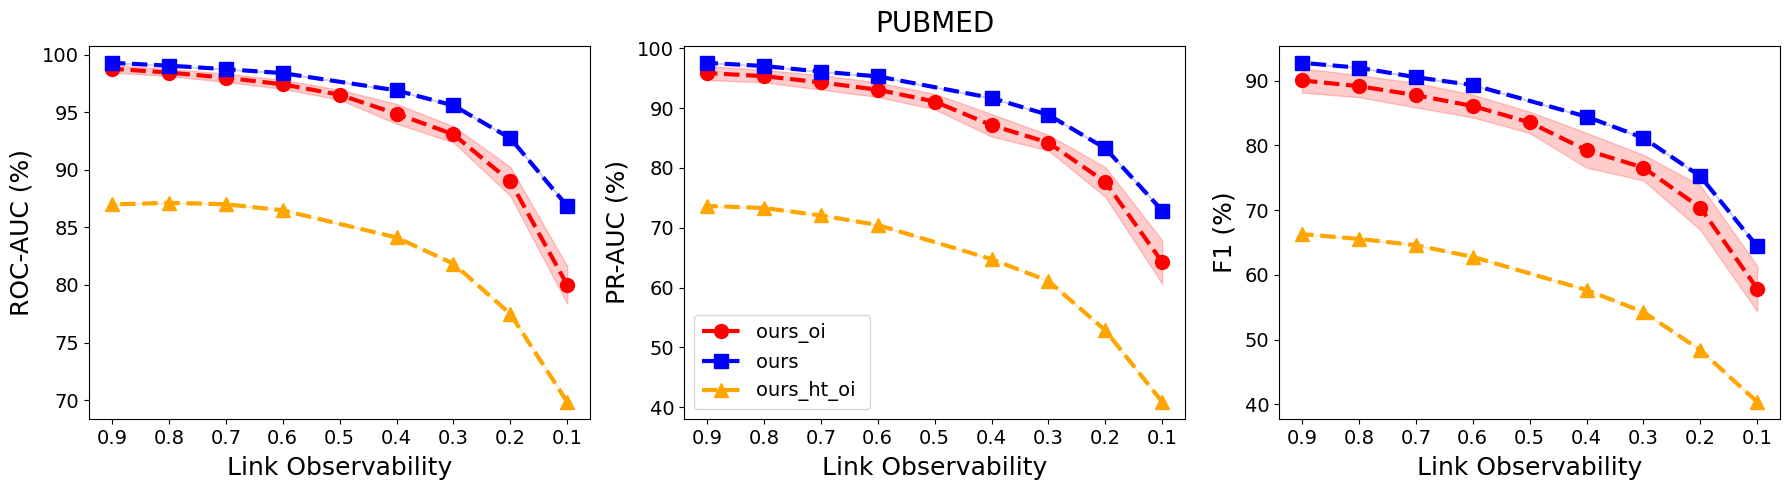

[INFO] 保存图表：pubmed_metrics.pdf


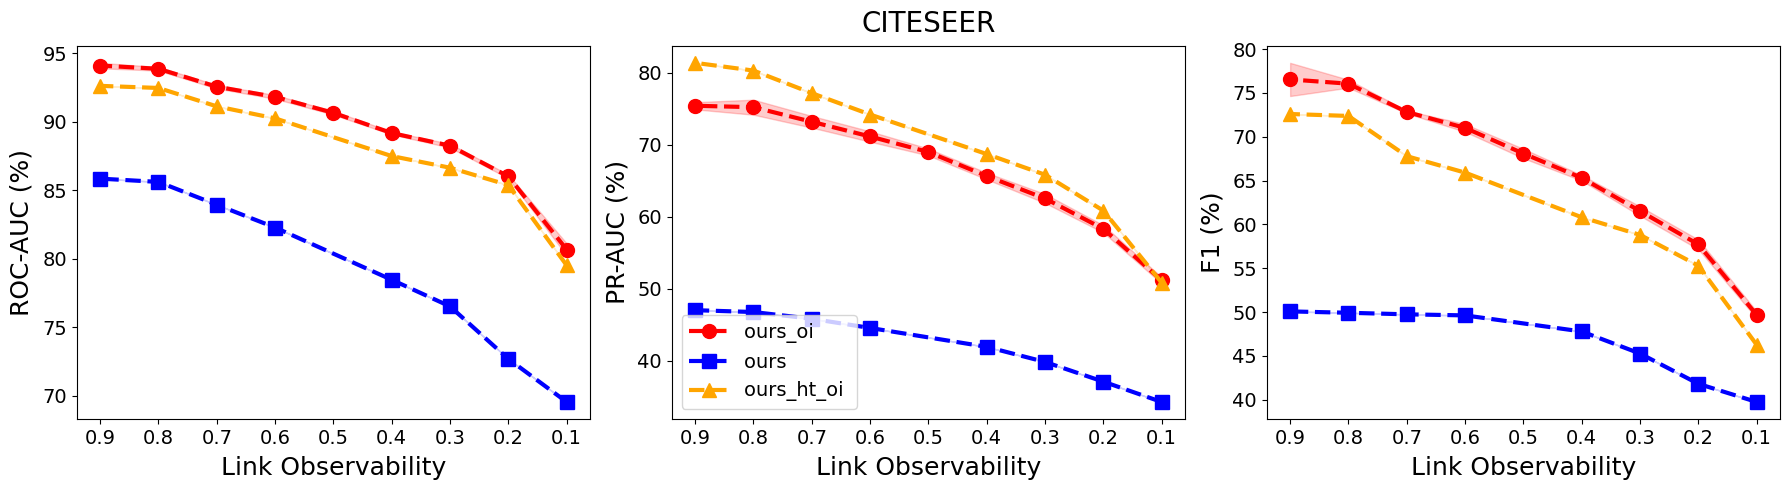

[INFO] 保存图表：citeseer_metrics.pdf


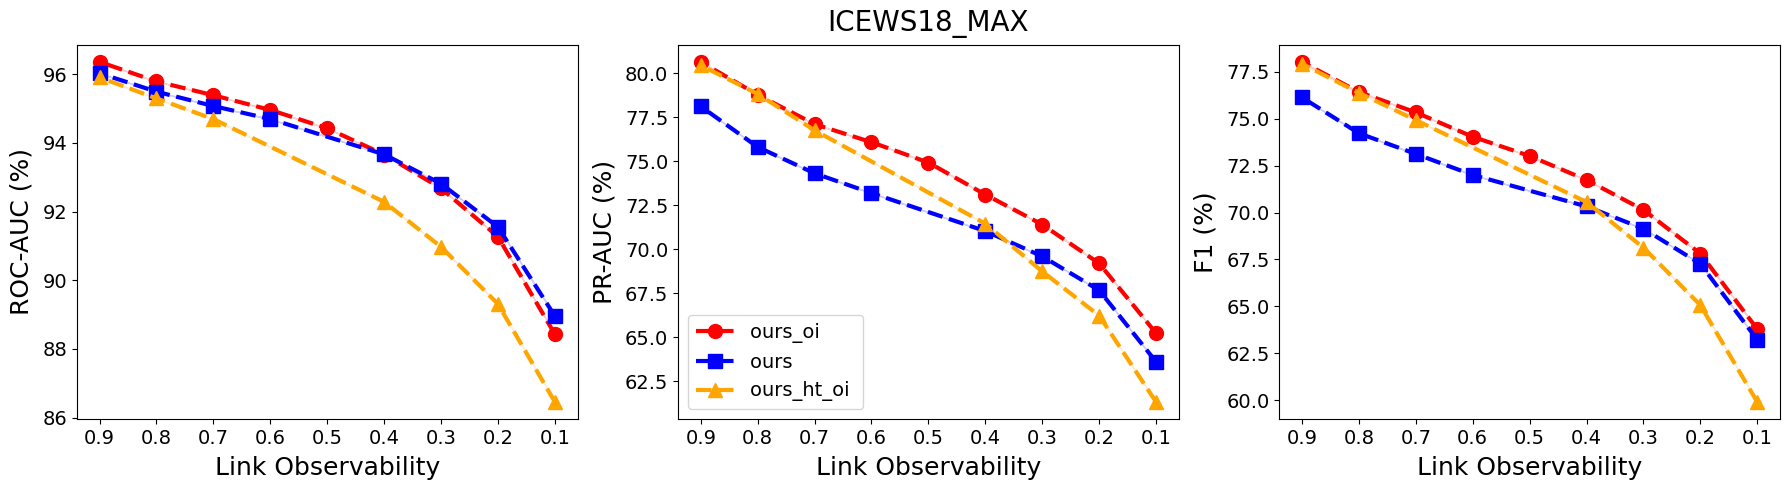

[INFO] 保存图表：icews18_max_metrics.pdf


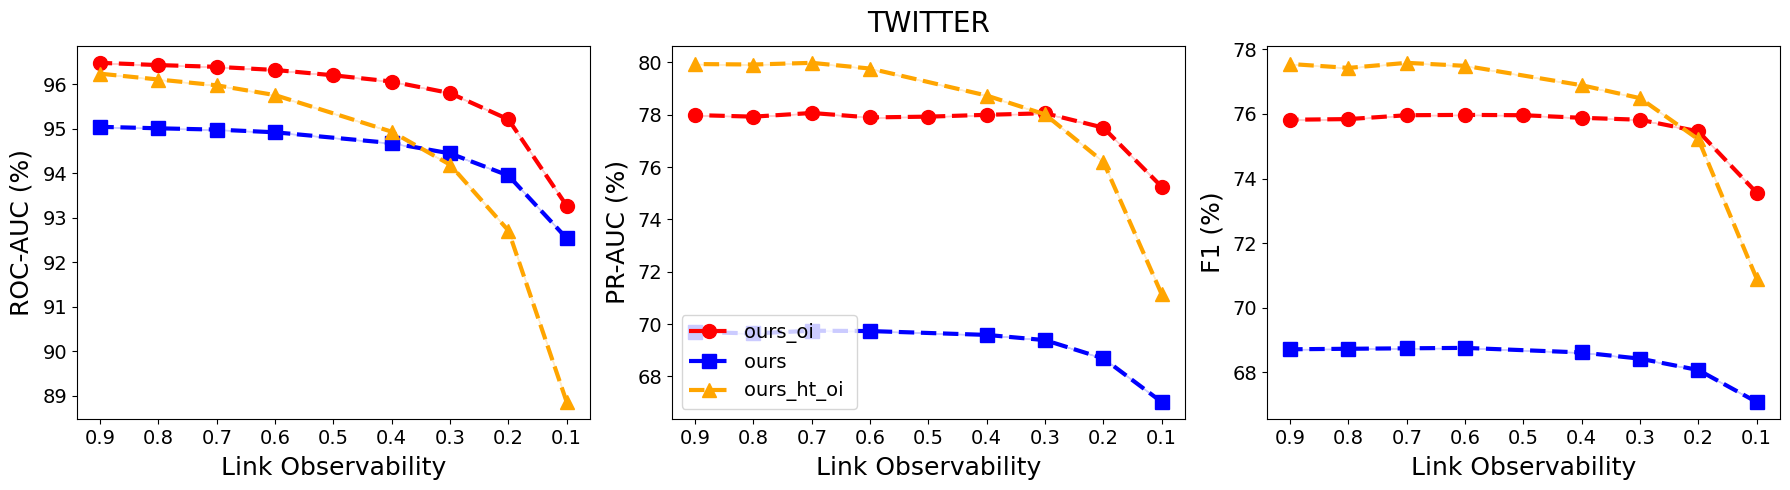

[INFO] 保存图表：twitter_metrics.pdf
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs/results/ogbl_citation2_result.csv，跳过。
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs_ht_oi/results/ogbl_citation2_result.csv，跳过。
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs/results/ogbl_citation2_result.csv，跳过。
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs_ht_oi/results/ogbl_citation2_result.csv，跳过。
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs/results/ogbl_citation2_result.csv，跳过。
[WARN] 文件不存在：/home/gaochi/leaf_matching/logs_ht_oi/results/ogbl_citation2_result.csv，跳过。


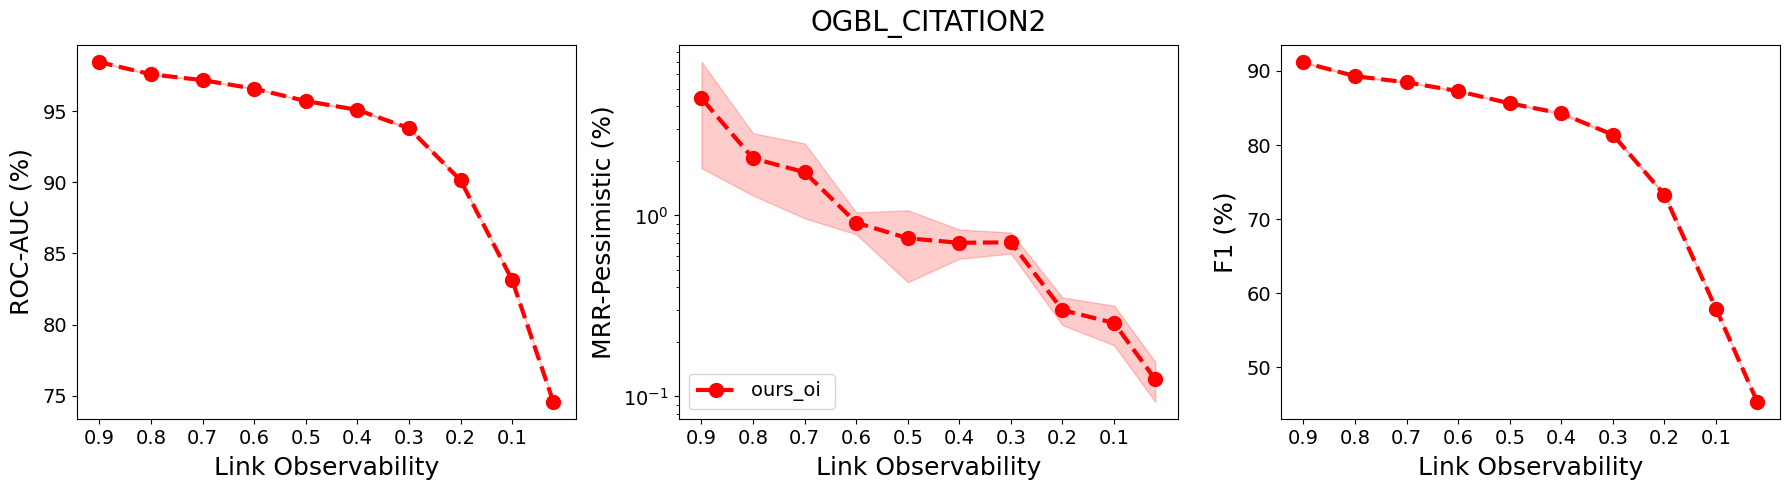

[INFO] 保存图表：ogbl_citation2_metrics.pdf


In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# 1) 手动指定每个算法的结果目录
#    目录下应包含 {dataset}_result.csv
#    例：cora_result.csv, pubmed_result.csv, ...
# -----------------------------
algo_dirs = {
    "ours_oi":  "/home/gaochi/leaf_matching/logs_oi/results",      # ←←← TODO: 修改为你的实际路径
    # "ours_ht":  "/home/gaochi/leaf_matching/logs_ht/results",      # ←←← TODO: 修改为你的实际路径
    "ours"   :  "/home/gaochi/leaf_matching/logs/results",      # ←←← TODO: 修改为你的实际路径
    "ours_ht_oi": "/home/gaochi/leaf_matching/logs_ht_oi/results",      # ←←← TODO: 修改为你的实际路径
}

# -----------------------------
# 2) 绘图配置
# -----------------------------
algorithms = ['ours_oi', 'ours', 'ours_ht_oi']
suffixes   = ['', '', '']
datasets   = ['yeast', 'fly_larva', 'cora', 'cora_ml', 'pubmed', 'citeseer', 'icews18_max', 'twitter', 'ogbl_citation2']
metrics    = ['roc_auc', 'ap', 'f1']
metrics_citation2 = ['roc_auc', 'mrr_pess', 'f1']
metrics_show = {
    'roc_auc': 'ROC-AUC (%)',
    'ap':      'PR-AUC (%)',
    'f1':      'F1 (%)',
    'mrr_pess': 'MRR-Pessimistic (%)',
}
split_ticks = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

colors      = ['red', 'blue', 'orange']
line_styles = ['--', '--', '--']
markers     = ['o', 's', '^']

# -----------------------------
# 3) 指标列名同义词映射（大小写不敏感）
# -----------------------------
COLUMN_SYNONYMS = {
    'roc_auc': ['roc_auc', 'roc', 'auc', 'roc-auc', 'rocauc'],
    'ap':      ['ap', 'AP', 'pr_auc', 'pr', 'PR', 'pr-auc', 'average_precision', 'avg_precision'],
    'f1':      ['f1', 'F1', 'f1_score', 'f1-score'],
    'mrr_pess': ['mrr_pess', 'mrr', 'MRR', 'mrr-pessimistic'],
}
SPLIT_COL_CANDIDATES = ['split_ratio', 'split', 'ratio']

# -----------------------------
# 4) 工具函数：解析 "mean±std" / "mean (+/-) std" / "mean(std)" / "mean"
# -----------------------------
_float_re = re.compile(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?')

def parse_mean_std(x):
    """
    输入：可能是数字、或形如 '0.812±0.013', '0.812 +/- 0.013', '0.812(0.013)', '0.812 +- 0.013', '0.812'
    输出：(mean, std)。若无 std，返回 std=0.0
    """
    if pd.isna(x):
        return np.nan, 0.0
    if isinstance(x, (int, float, np.number)):
        return float(x), 0.0

    s = str(x)
    nums = _float_re.findall(s)
    if not nums:
        return np.nan, 0.0
    mean = float(nums[0])
    std = float(nums[1]) if len(nums) >= 2 else 0.0
    return mean, std

def to_percent(arr):
    """
    若值在 [0,1.0001] 范围内，视为比例，×100 转百分比；否则保持不变。
    同时确保 np.array(dtype=float)。
    """
    arr = np.asarray(arr, dtype=float)
    return arr

def select_column(df, candidates):
    """
    在 df 列中（大小写不敏感）寻找候选名，返回命中的真实列名；否则返回 None
    """
    lower_map = {c.lower(): c for c in df.columns}
    for c in candidates:
        if c.lower() in lower_map:
            return lower_map[c.lower()]
    return None

def extract_metric_series(df, metric_key):
    """
    根据 metric_key（'roc_auc'/'ap'/'f1'）从 df 中抽取该列（支持多种同义表头、及 mean±std 写法）。
    返回：mean(np.array)、std(np.array)
    """
    col = select_column(df, COLUMN_SYNONYMS[metric_key])
    if col is None:
        raise KeyError(f"未在 CSV 中找到 {metric_key} 的列名（候选={COLUMN_SYNONYMS[metric_key]}），现有列={list(df.columns)}")

    means, stds = [], []
    for v in df[col].tolist():
        m, s = parse_mean_std(v)
        means.append(m)
        stds.append(s)

    means = np.array(means, dtype=float)
    stds  = np.array(stds,  dtype=float)

    # 数值统一为百分比刻度
    means = to_percent(means)
    stds  = to_percent(stds)
    return means, stds

def extract_split_ratio(df):
    col = select_column(df, SPLIT_COL_CANDIDATES)
    if col is None:
        raise KeyError(f"未在 CSV 中找到 split_ratio 列（候选={SPLIT_COL_CANDIDATES}），现有列={list(df.columns)}")
    # 转 float
    sr = pd.to_numeric(df[col], errors='coerce').to_numpy()
    return sr

# -----------------------------
# 5) 主循环：按数据集绘图
# -----------------------------
for dataset in datasets:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, metric_name in enumerate(metrics if dataset != 'ogbl_citation2' else metrics_citation2):
        ax = axes[i]

        # 轴标题与刻度
        if i == 1:
            ax.set_title(f'{dataset.upper()}', fontsize=20, pad=10)
        ax.set_xlabel('Link Observability', fontsize=18, labelpad=6)
        ax.set_ylabel(metrics_show[metric_name], fontsize=18, labelpad=6)
        ax.set_xticks(split_ticks)
        ax.tick_params(axis='x', labelsize=14)
        ax.tick_params(axis='y', labelsize=14)
        
        if metric_name == 'mrr_pess':
            ax.set_yscale('log')
        
        for k, (algo, suffix) in enumerate(zip(algorithms, suffixes)):
            # 构造文件路径：{algo_dir}/{dataset}_result.csv
            if algo not in algo_dirs:
                print(f"[WARN] 未为算法 {algo} 指定目录，跳过。")
                continue
            file_path = os.path.join(algo_dirs[algo], f"{dataset}_result.csv")

            if not os.path.isfile(file_path):
                print(f"[WARN] 文件不存在：{file_path}，跳过。")
                continue

            # 读取 CSV
            try:
                df = pd.read_csv(file_path)
            except Exception as e:
                print(f"[ERROR] 读取失败：{file_path} -> {e}")
                continue

            # 提取 split_ratio + 对应指标
            try:
                split_ratio = extract_split_ratio(df)
                metric_mean, metric_std = extract_metric_series(df, metric_name)
            except Exception as e:
                print(f"[WARN] 解析失败（{algo}, {dataset}, {metric_name}）：{e}")
                continue

            # 丢弃 NaN
            mask = ~np.isnan(split_ratio) & ~np.isnan(metric_mean) & ~np.isnan(metric_std)
            split_ratio = split_ratio[mask]
            metric_mean = metric_mean[mask]
            metric_std  = metric_std[mask]

            if len(split_ratio) == 0:
                print(f"[WARN] {algo}-{dataset}-{metric_name} 无有效数据，跳过。")
                continue

            # 依据 split_ratio 排序（升序），随后反转 x 轴
            idx = np.argsort(split_ratio)
            split_ratio = split_ratio[idx]
            metric_mean = metric_mean[idx]
            metric_std  = metric_std[idx]

            # 绘制曲线 + 标准差阴影
            ax.plot(
                split_ratio, metric_mean,
                label=f"{algo} {suffix}",
                color=colors[k],
                linestyle=line_styles[k],
                linewidth=3,
                marker=markers[k],
                markersize=10
            )
            ax.fill_between(
                split_ratio,
                metric_mean - metric_std,
                metric_mean + metric_std,
                color=colors[k],
                alpha=0.2
            )

        if i == 1:
            ax.legend(fontsize=14, loc='lower left')

        # 和你原逻辑一致：反转 x 轴
        ax.invert_xaxis()

    plt.tight_layout()
    out_path = f"{dataset}_metrics.pdf"
    plt.savefig(out_path)
    plt.show()
    print(f"[INFO] 保存图表：{out_path}")
